In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
import glob
import os
from IPython.display import Image

In [5]:
from QuantumMST import scatterer, protein_structure, interpolation
from QuantumMST import plot_potential, plot_wavefunction
from QuantumMST.wavefunction import calc_psi
from QuantumMST.matrix_solvers import NumpySolver, Numpy_energies

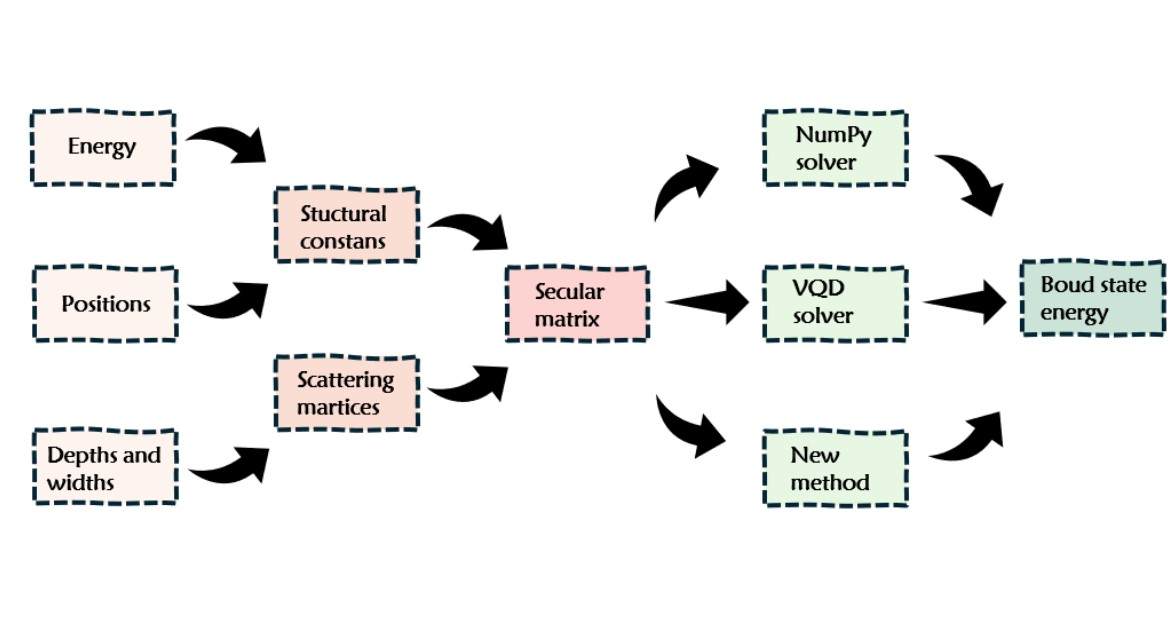

In [6]:
display(Image(filename='thesis_plots_data/schemat_beztla.jpg'))

secular matrix:


,0,1,2,3
0,-0.033143-0.000000j,0.000000+0.000000j,-0.031301-0.000000j,-0.000000-0.031301j
1,0.000000+0.000000j,-0.246453+0.000000j,-0.000000+0.031301j,-0.031301-0.000000j
2,-0.031301-0.000000j,-0.000000+0.031301j,-0.062880-0.000000j,0.000000+0.000000j
3,-0.000000-0.031301j,-0.031301-0.000000j,0.000000+0.000000j,-0.650747+0.000000j


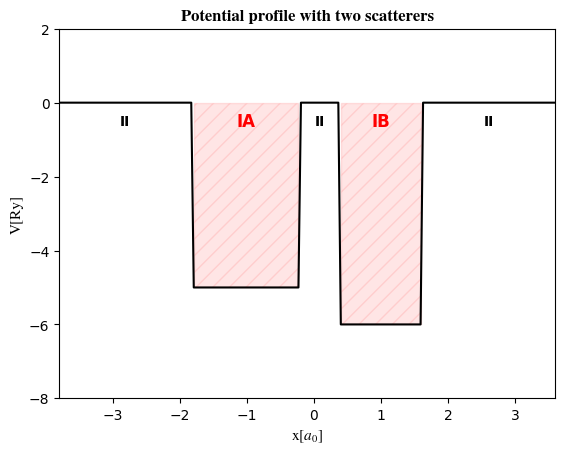

In [3]:

#! data from Butler's article ===> reference_system = 1

structure_Butler = protein_structure(energy = -3, reference_system = 1)

print("secular matrix:")
display(pd.DataFrame(structure_Butler.secular_matrix()))

V, x = structure_Butler.potential(resolution = 100)
plot_potential(x, V, structure_Butler, title = 'Potential profile with two scatterers', title_size=12)


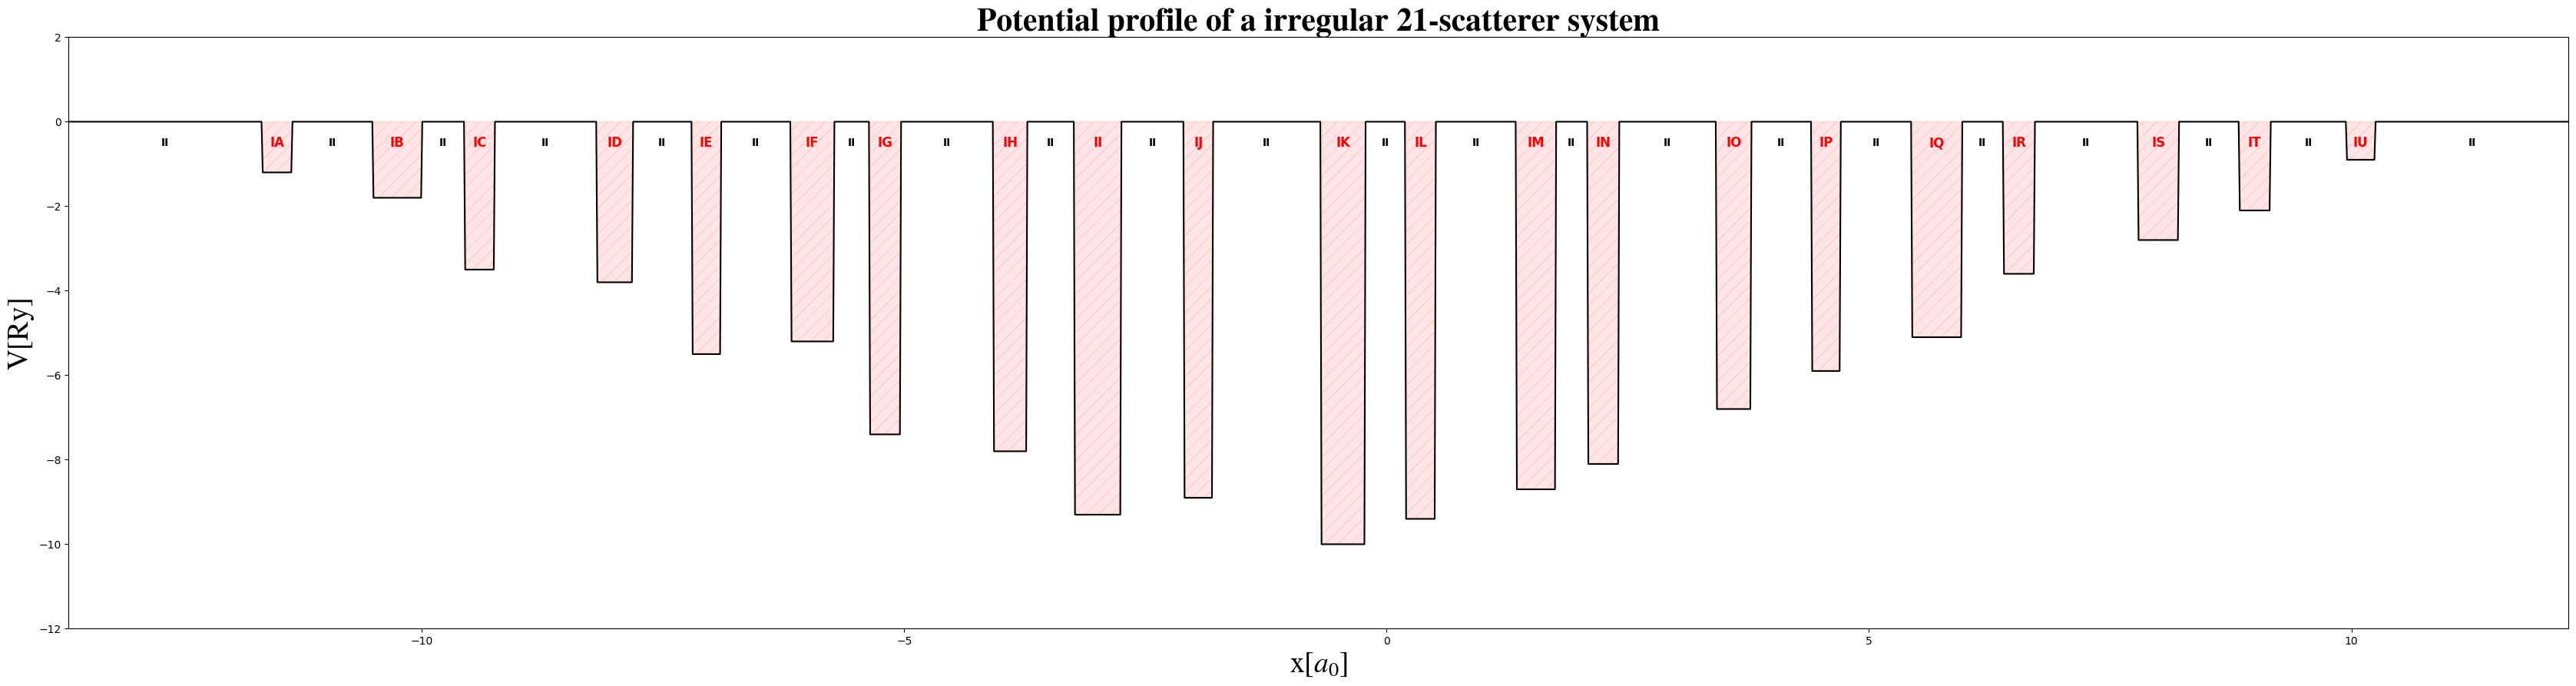

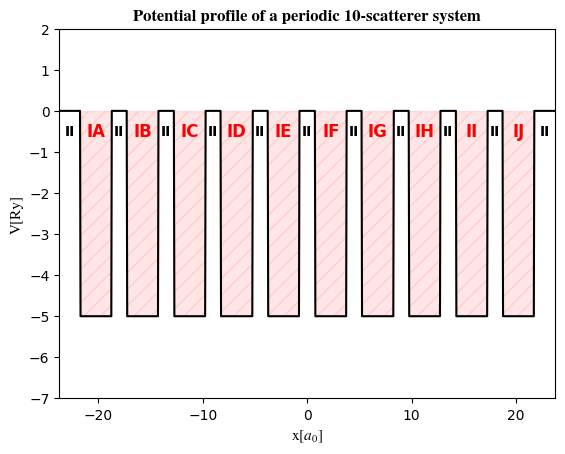

In [4]:
structure_2 =protein_structure(-3, reference_system=5)
V, x = structure_2.potential(resolution = 100)
plot_potential(x, V, structure_2,  title = 'Potential profile of a irregular 21-scatterer system', title_size=30, axis_size=27)

structure_3 = protein_structure(-3, reference_system=6)
V, x = structure_3.potential(resolution = 100)
plot_potential(x, V, structure_3,  title = 'Potential profile of a periodic 10-scatterer system', title_size=12)


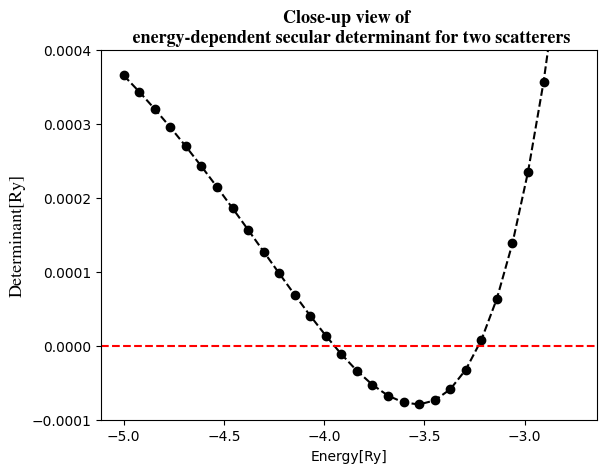

In [5]:
title_font = {
        'fontname': 'STIXGeneral',
        'size': 13,
        'weight': 'semibold',
        'color': 'black'
}

axis_font = {
        'fontname': 'STIXGeneral',
        'size': 13,  
}

from QuantumMST import determinant
s = structure_Butler.scatterers
x = structure_Butler.positions

nE = 30
energies = np.linspace(-5,-2.75, nE)

results = determinant(energies, arr_s= s, arr_x= x)
plt.plot(energies, results, 'o--', color = 'black')
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Determinant[Ry]', fontdict = axis_font)
plt.xlabel('Energy[Ry]', )
plt.title(f'Close-up view of \n energy-dependent secular determinant for two scatterers', fontdict = title_font)
plt.ylim(-0.0001, 0.0004)
plt.show()


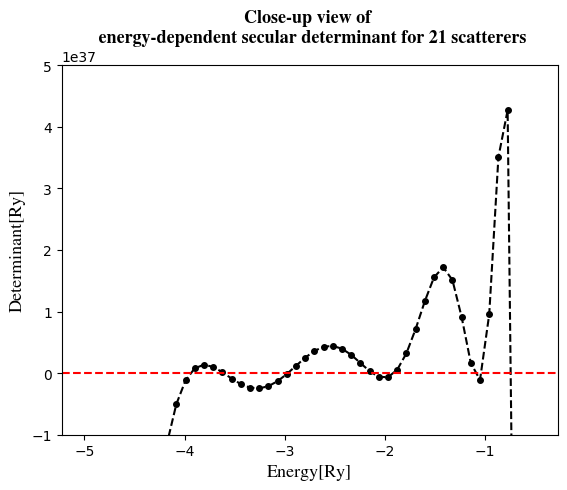

In [6]:
s = structure_2.scatterers
x = structure_2.positions

nE = 50
energies = np.linspace(-5, -0.5, nE)

results = determinant(energies, arr_s= s, arr_x= x)
plt.plot(energies, results, 'o--', color = 'black', markersize = 4)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Determinant[Ry]', fontdict = axis_font)
plt.xlabel('Energy[Ry]', fontdict = axis_font)
plt.ylim(-1e37, 5e37)
plt.title(f'Close-up view of \n energy-dependent secular determinant for 21 scatterers', fontdict = title_font)

plt.show()


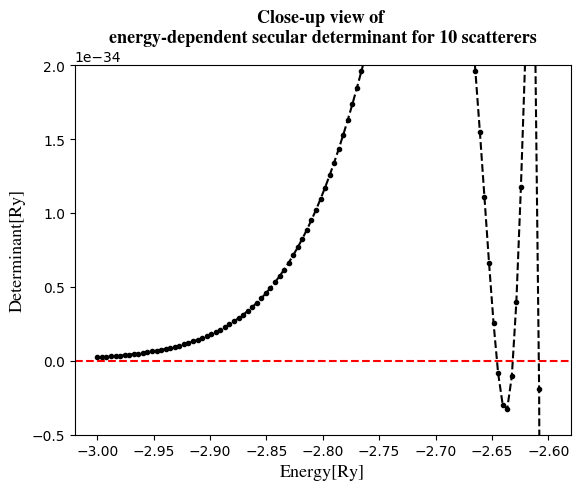

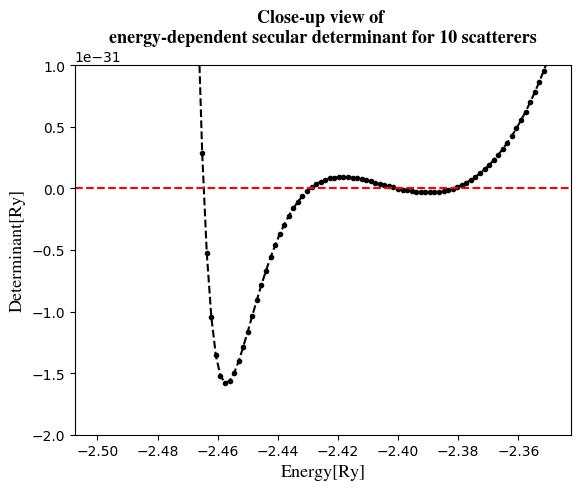

In [7]:
s = structure_3.scatterers
x = structure_3.positions

nE = 100
energies = np.linspace(-3, -2.6, nE)

results = determinant(energies, arr_s= s, arr_x= x)
plt.plot(energies, results, 'o--', color = 'black', markersize = 3)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Determinant[Ry]', fontdict = axis_font)
plt.xlabel('Energy[Ry]', fontdict = axis_font)
plt.ylim(-0.5e-34, 2e-34)
plt.title(f'Close-up view of \nenergy-dependent secular determinant for 10 scatterers', fontdict = title_font)

plt.show()

s = structure_3.scatterers
x = structure_3.positions

nE = 100
energies = np.linspace(-2.5, -2.35, nE)

results = determinant(energies, arr_s= s, arr_x= x)
plt.plot(energies, results, 'o--', color = 'black', markersize = 3)
plt.axhline(0, color='red', linestyle='--')
plt.ylabel('Determinant[Ry]', fontdict = axis_font)
plt.xlabel('Energy[Ry]', fontdict = axis_font)
plt.ylim(-2e-31, 1e-31)
plt.title(f'Close-up view of \nenergy-dependent secular determinant for 10 scatterers', fontdict = title_font)

plt.show()



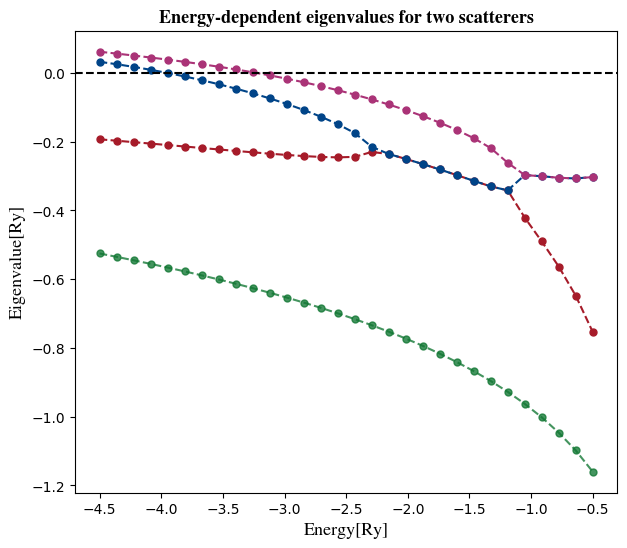

In [8]:
s = structure_Butler.scatterers
x = structure_Butler.positions

nE = 30
energies = np.linspace(-4.5, -0.5, nE)

results = Numpy_energies(energies, arr_s= s, arr_x= x)

eval_1, eval_2, eval_3, eval_4 = results 

numpy_colors = ["#117733C8", "#A61B29", "#004488", "#AA3377"]


plt.figure(figsize=(7, 6))

plt.plot(energies, eval_1, 'o--', color=numpy_colors[0], markersize=5)
plt.plot(energies, eval_2, 'o--', color=numpy_colors[1], markersize=5)
plt.plot(energies, eval_3, 'o--', color=numpy_colors[2], markersize=5)
plt.plot(energies, eval_4, 'o--', color=numpy_colors[3], markersize=5)

plt.axhline(0, color='black', linestyle='--')
plt.ylabel('Eigenvalue[Ry]', fontdict = axis_font)
plt.xlabel('Energy[Ry]', fontdict = axis_font)
plt.title('Energy-dependent eigenvalues for two scatterers',  fontdict = title_font)
plt.show()

# results = determinant(energies, arr_s= s, arr_x= x)
# plt.plot(energies, results, 'o--', color = 'black')
# plt.axhline(0, color='red', linestyle='--')
# plt.ylabel('Determinant[Ry]')
# plt.xlabel('Energy[Ry]')
# plt.title('Two scatterers in 1D', fontsize=12, fontweight='semibold')
# plt.xlim(-4.5, -3)
# plt.ylim(-0.0001, 0.0003)
plt.show()

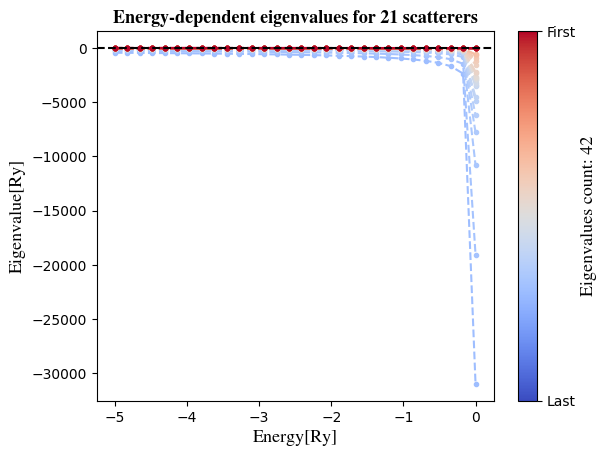

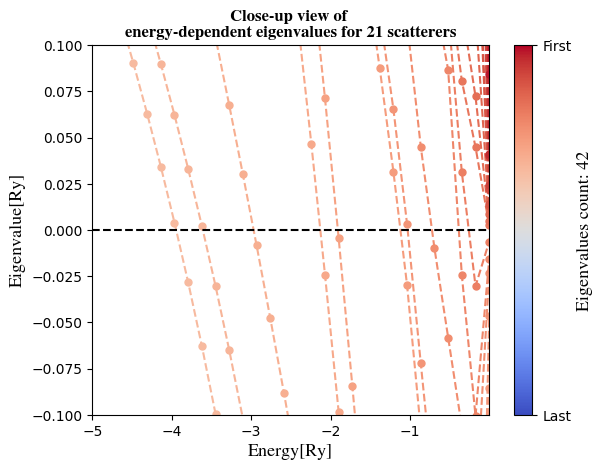

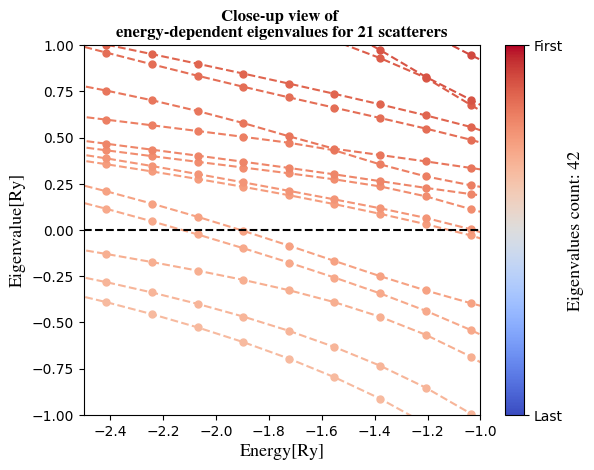

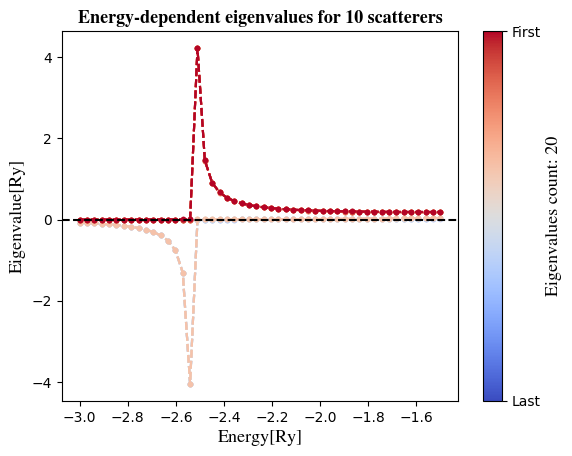

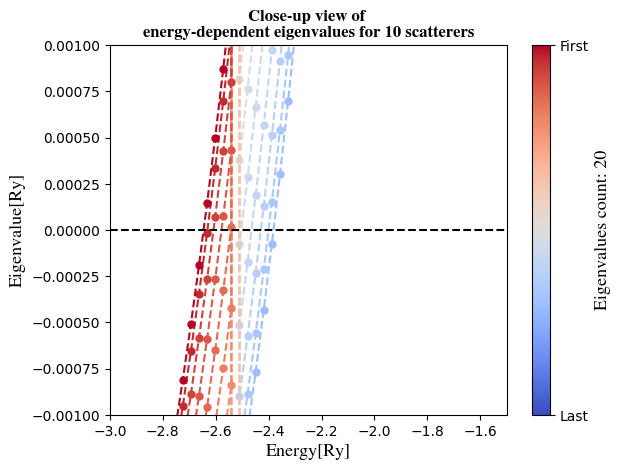

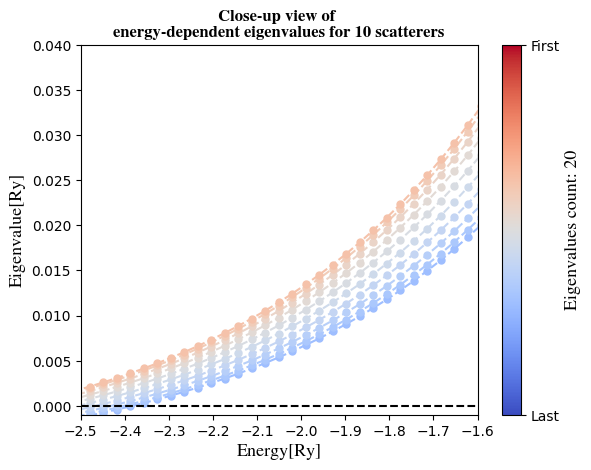

In [9]:
examples = [structure_2, structure_3]
titles = ['Energy-dependent eigenvalues for 21 scatterers', 'Energy-dependent eigenvalues for 10 scatterers']
close_up_range_y= [(-0.1, 0.1, -1, 1), (-0.001, 0.001, -0.001, 0.04)]
close_up_range_x= [(-5, -0.001, -2.5, -1), (-3, -1.5, -2.5, -1.6)]
energy_range_nE = [(-5, -0.001, 30), (-3, -1.5, 50)]

for i_ex in range(len(examples)):
    ex = examples[i_ex]
    t = titles[i_ex]
    s = ex.scatterers
    x = ex.positions

    energies = np.linspace(energy_range_nE[i_ex][0], energy_range_nE[i_ex][1], energy_range_nE[i_ex][2])

    results = Numpy_energies(energies, arr_s= s, arr_x= x)

    cmap = plt.cm.coolwarm
    num_lines = results.shape[0]  
    colors = [cmap(i) for i in np.linspace(0.3, 1, num_lines)]

    for i in range (len(results)):
        plt.plot(energies, results[i], 'o--',  markersize=3, color = colors[i])

    norm = plt.Normalize(vmin=1, vmax=num_lines)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar1 = plt.colorbar(sm, ax=plt.gca(), ticks=[1, num_lines])
    cbar1.set_label(f'Eigenvalues count: {num_lines}', fontdict=axis_font)
    cbar1.ax.set_yticklabels(['Last', 'First'])

    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel('Eigenvalue[Ry]',fontdict = axis_font)
    plt.xlabel('Energy[Ry]',fontdict = axis_font)
    plt.title(t,  fontdict = title_font)
    plt.show()

    close = 0
    for _ in range(2):
        for i in range (len(results)):
            plt.plot(energies, results[i], 'o--',  markersize=5, color = colors[i])
            
        cbar2 = plt.colorbar(sm, ax=plt.gca(), ticks=[1, num_lines])
        cbar2.set_label(f'Eigenvalues count: {num_lines}', fontdict=axis_font)
        cbar2.ax.set_yticklabels(['Last', 'First'])
        
        plt.axhline(0, color='black', linestyle='--')
        plt.ylabel('Eigenvalue[Ry]',fontdict = axis_font)
        plt.xlabel('Energy[Ry]',fontdict = axis_font)
        plt.ylim(close_up_range_y[i_ex][0+close], close_up_range_y[i_ex][1+close])
        plt.xlim(close_up_range_x[i_ex][0+close], close_up_range_x[i_ex][1+close])
        plt.title(f'Close-up view of \ne' + t[1:],  fontdict = title_font, size = 12)
        plt.show()
        close+=2

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.500000 : -3.000000,-3.228442
1,1,-4.000000 : -3.500000,-3.949616


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.500000 : -3.000000,-3.194724
1,1,-4.500000 : -4.000000,-4.139905


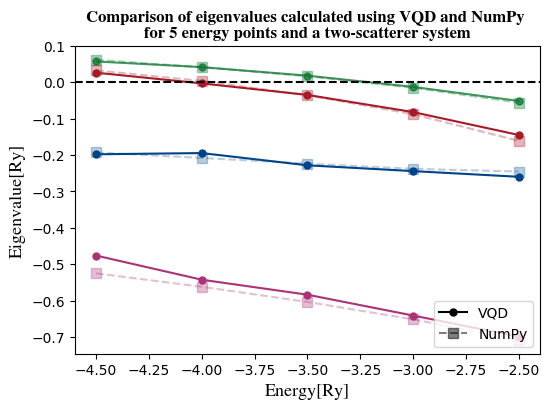

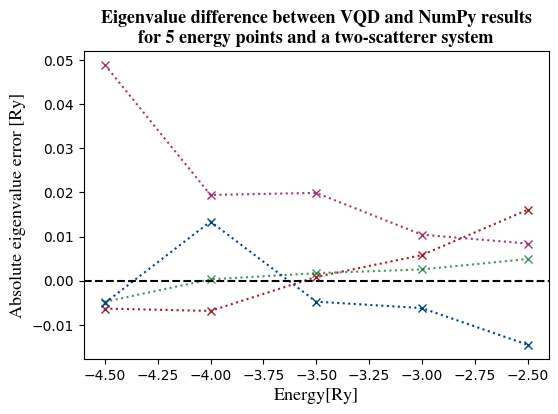

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.388889 : -3.166667,-3.228486
1,1,-4.055556 : -3.833333,-3.949877


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.388889 : -3.166667,-3.211536
1,1,-4.055556 : -3.833333,-3.942910


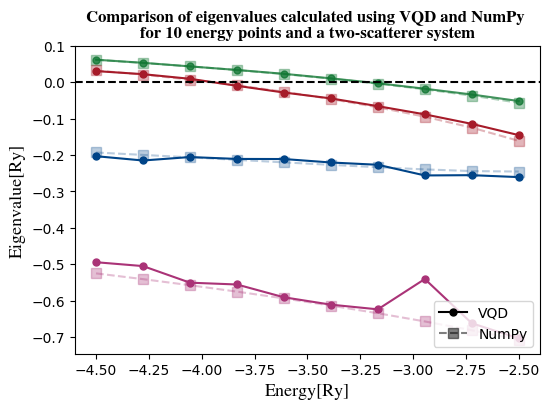

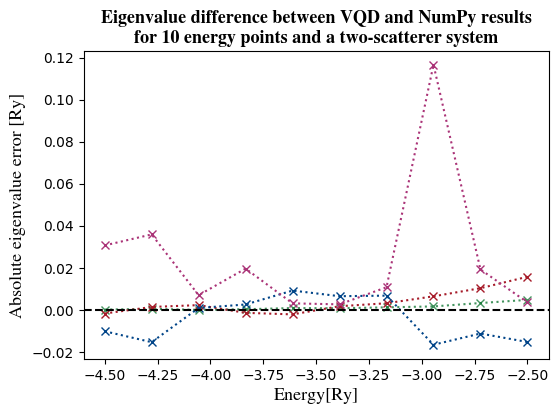

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.236842 : -3.131579,-3.228487
1,1,-3.973684 : -3.868421,-3.949901


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.236842 : -3.131579,-3.197092
1,1,-3.973684 : -3.868421,-3.923853


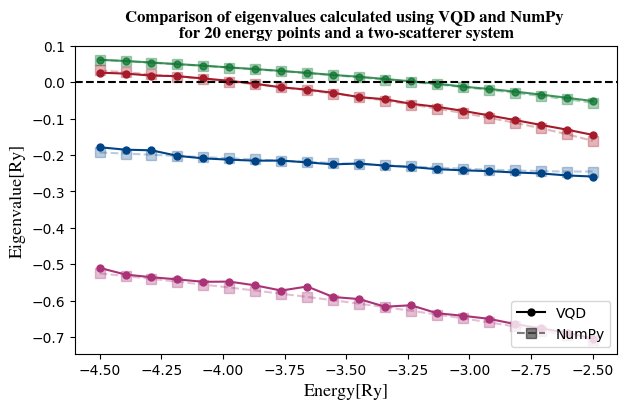

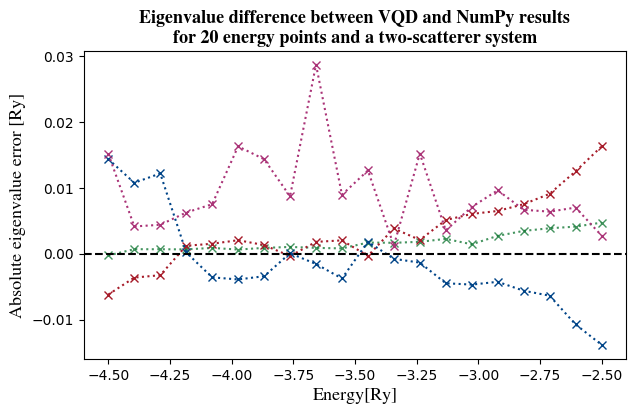

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.269231 : -3.217949,-3.228487
1,1,-3.987179 : -3.935897,-3.949902


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.217949 : -3.166667,-3.196230
1,1,-3.987179 : -3.935897,-3.960669


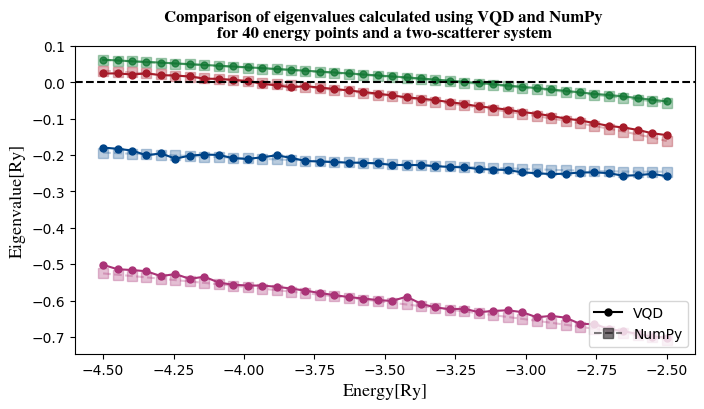

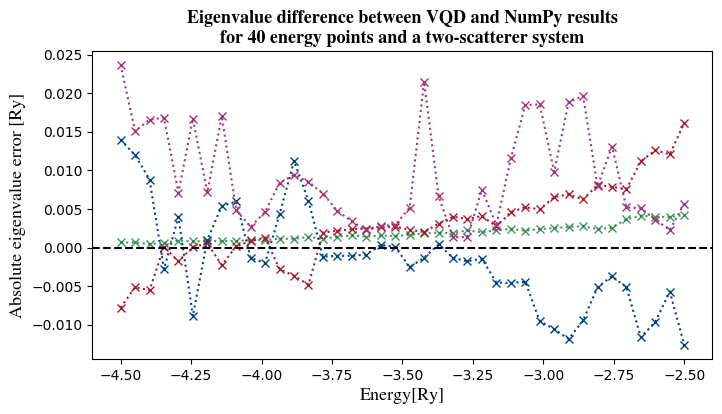

NumPy results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.234177 : -3.208861,-3.228487
1,1,-3.968354 : -3.943038,-3.949902


VQD results:


,Eigenvalue number,In between the points,Interpolated value
0,0,-3.208861 : -3.183544,-3.199841
1,1,-3.993671 : -3.968354,-3.975233


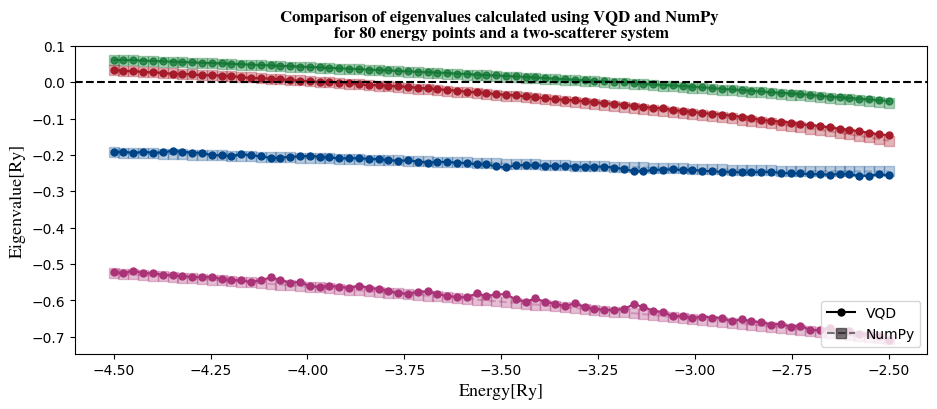

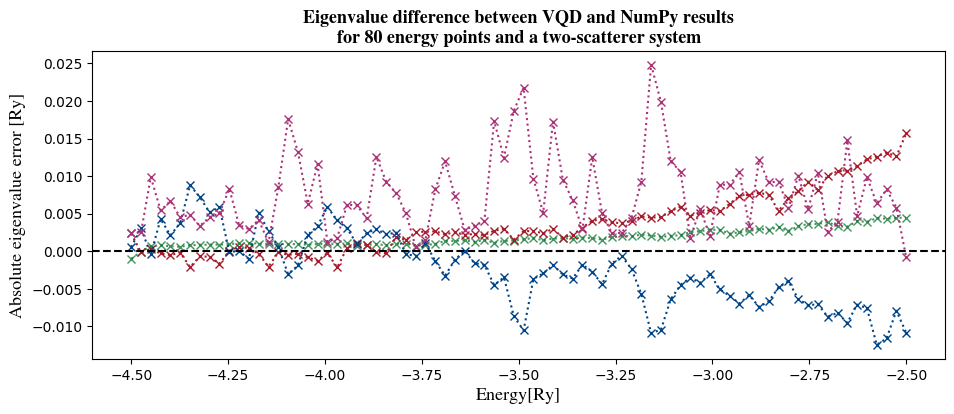

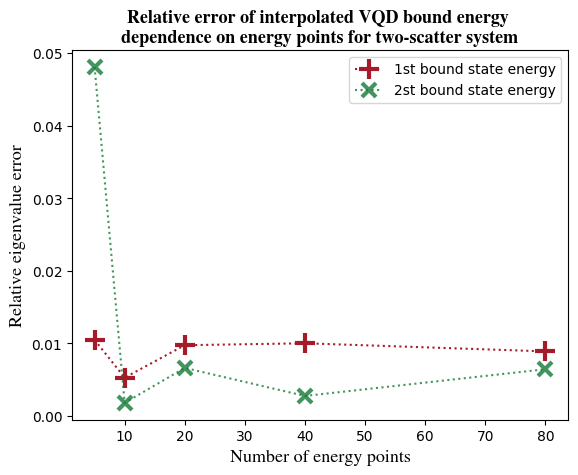

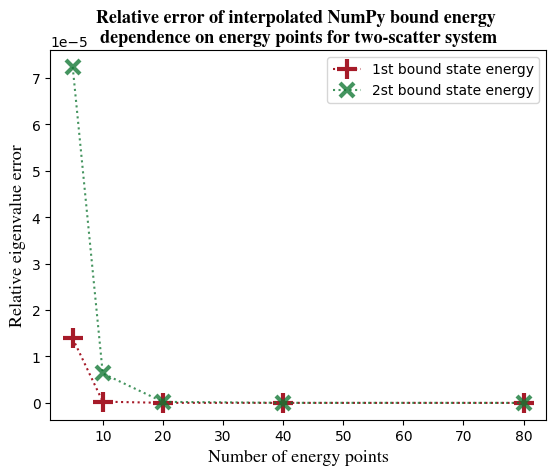

In [10]:
input_dir = "thesis_plots_data/vqd_energy_resolution/vqd_2/"
files = sorted(glob.glob(input_dir + "*.txt"))

index = 0
wyniki_e1 =[]
wyniki_e2 =[]

wyniki_e1_np =[]
wyniki_e2_np =[]
num_points = [5, 10, 20, 40, 80]
for file in files:

    energies, e1, e2, e3, e4, eval_1, eval_2, eval_3, eval_4 = np.loadtxt(file).T

    arr_eigen_val = []
    arr_eigen_val_NP = []
    for ev in range(0, len(e1)):
        arr_eigen_val.append(e1[ev])
        arr_eigen_val.append(e2[ev])
        arr_eigen_val.append(e3[ev])
        arr_eigen_val.append(e4[ev])

        arr_eigen_val_NP.append(eval_1[ev])
        arr_eigen_val_NP.append(eval_2[ev])
        arr_eigen_val_NP.append(eval_3[ev])
        arr_eigen_val_NP.append(eval_4[ev])

    energies_arr = []
    for i in range(4):
        energies_arr.extend(energies)

    # print(np.shape(arr_eigen_val), np.shape(energies_arr))

    print('NumPy results:')
    wyniki_np = interpolation(len(energies), arr_eigen_val_NP, energies)

    print('VQD results:')
    wyniki = interpolation(len(energies), arr_eigen_val, energies)

    plt.close('all')

    vqd_colors = ["#117733C8", "#A61B29", "#004488", "#AA3377"]
    numpy_colors = ["#11773357", "#A61B2952", "#00448845", "#AA337750"]
    plt.figure(figsize=(6+num_points[index]//15, 4))
    plt.plot(energies, e1, 'o-', color=vqd_colors[0], markersize=5)
    plt.plot(energies, e2, 'o-', color=vqd_colors[1], markersize=5)
    plt.plot(energies, e3, 'o-', color=vqd_colors[2], markersize=5)
    plt.plot(energies, e4, 'o-', color=vqd_colors[3], markersize=5)

    plt.plot(energies, eval_1, 's--', color=numpy_colors[0], markersize=7)
    plt.plot(energies, eval_2, 's--', color=numpy_colors[1], markersize=7)
    plt.plot(energies, eval_3, 's--', color=numpy_colors[2], markersize=7)
    plt.plot(energies, eval_4, 's--', color=numpy_colors[3], markersize=7)

    custom_handles = [Line2D([0], [0], marker='o', linestyle='-', color='black', markersize=5),
                        Line2D([0], [0], marker='s', linestyle='--', color='black', markersize=7, alpha = 0.5),]



    custom_labels = ['VQD', 'NumPy']
    plt.legend(custom_handles, custom_labels, loc='lower right')

    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel('Eigenvalue[Ry]', fontdict = axis_font)
    plt.xlabel('Energy[Ry]', fontdict = axis_font)
    plt.title(f"Comparison of eigenvalues calculated using VQD and NumPy \nfor {num_points[index]} energy points and a two-scatterer system", fontdict = title_font, size = 12)

    plt.show()

    plt.figure(figsize=(6+num_points[index]//15, 4))
    plt.plot(energies, e1 - eval_1, 'x:', color=vqd_colors[0])
    plt.plot(energies, e2 - eval_2, 'x:', color=vqd_colors[1])
    plt.plot(energies, e3 - eval_3, 'x:', color=vqd_colors[2])
    plt.plot(energies, e4 - eval_4, 'x:', color=vqd_colors[3])
    plt.axhline(0, color='black', linestyle='--')
    plt.ylabel('Absolute eigenvalue error [Ry]', fontdict = axis_font)
    plt.xlabel('Energy[Ry]', fontdict = axis_font)
    plt.title(f"Eigenvalue difference between VQD and NumPy results\nfor {num_points[index]} energy points and a two-scatterer system", fontdict = title_font)
    plt.show()

    wyniki_e1.append(wyniki[0][0])
    wyniki_e2.append(wyniki[1][0])
    # print(wyniki_e1, len(wyniki_e1))

    wyniki_e1_np.append(wyniki_np[0][0])
    wyniki_e2_np.append(wyniki_np[1][0])

    index +=1

exact_e1 = -3.22848704
exact_e2 = -3.949901757
plt.figure()
plt.plot(num_points, np.abs((np.array(wyniki_e1)-exact_e1)/exact_e1),  '+:', color =  vqd_colors[1], label = '1st bound state energy', markersize = 15, markeredgewidth=3)
plt.plot(num_points, np.abs((np.array(wyniki_e2)-exact_e2)/exact_e2), 'x:', color = vqd_colors[0], label = '2st bound state energy',  markersize = 10, markeredgewidth=3)

plt.ylabel('Relative eigenvalue error', fontdict = axis_font)
plt.xlabel('Number of energy points', fontdict = axis_font)
plt.title(f"Relative error of interpolated VQD bound energy \ndependence on energy points for two-scatter system", fontdict = title_font)
plt.legend()
plt.show()

plt.figure()
plt.plot(num_points, np.abs((np.array(wyniki_e1_np)-exact_e1)/exact_e1), '+:', color =  vqd_colors[1], label = '1st bound state energy', markersize = 15, markeredgewidth=3)
plt.plot(num_points, np.abs((np.array(wyniki_e2_np)-exact_e2)/exact_e2), 'x:', color = vqd_colors[0], label = '2st bound state energy',  markersize = 10, markeredgewidth=3)
plt.ylabel('Relative eigenvalue error', fontdict = axis_font)
plt.xlabel('Number of energy points', fontdict = axis_font)
plt.title(f"Relative error of interpolated NumPy bound energy \ndependence on energy points for two-scatter system", fontdict = title_font)
plt.legend()
plt.show()

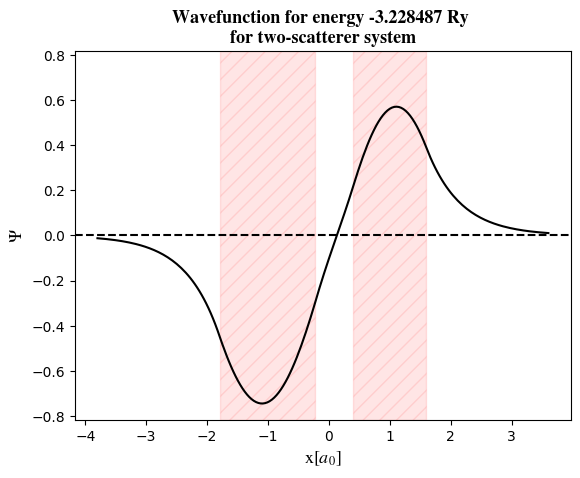

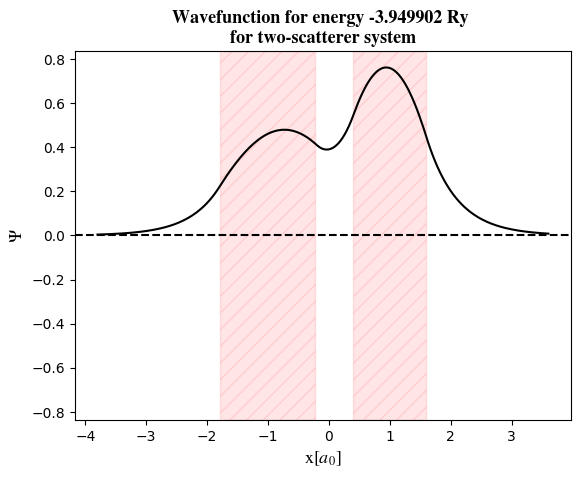

In [16]:
exact_e1 = -3.22848704
exact_e2 = -3.949901757

structure_Butler = protein_structure(energy = -3, reference_system = 1)
V, x = structure_Butler.potential(resolution = 100)

plot_wavefunction(x, V, protein_structure(exact_e1, reference_system=1))

plot_wavefunction(x, V, protein_structure(exact_e2, reference_system=1))

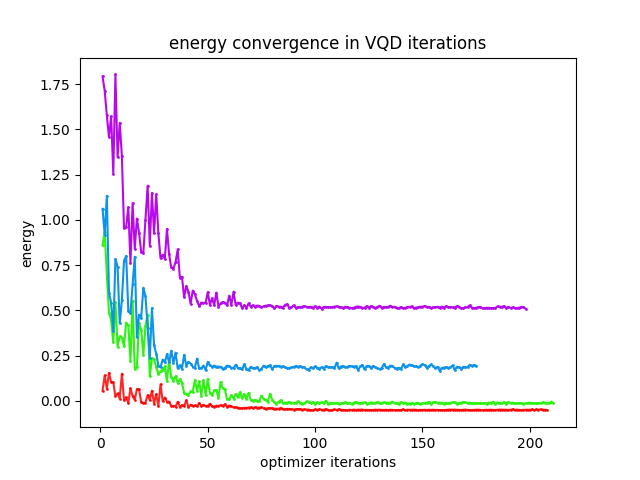

In [ ]:
Image(filename='thesis_plots_data/placeholders/iterations_vqd.png')

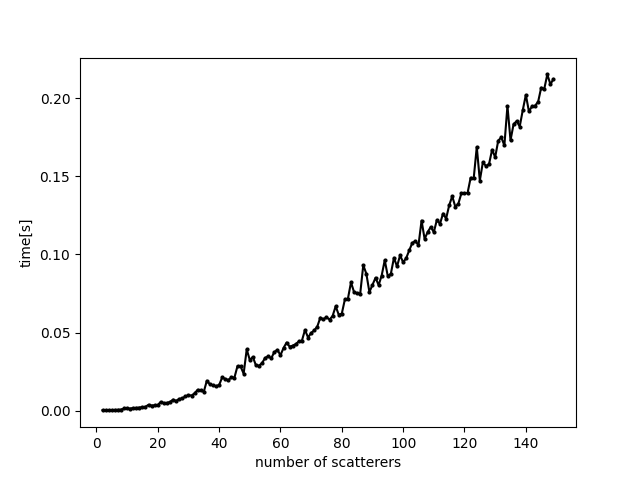

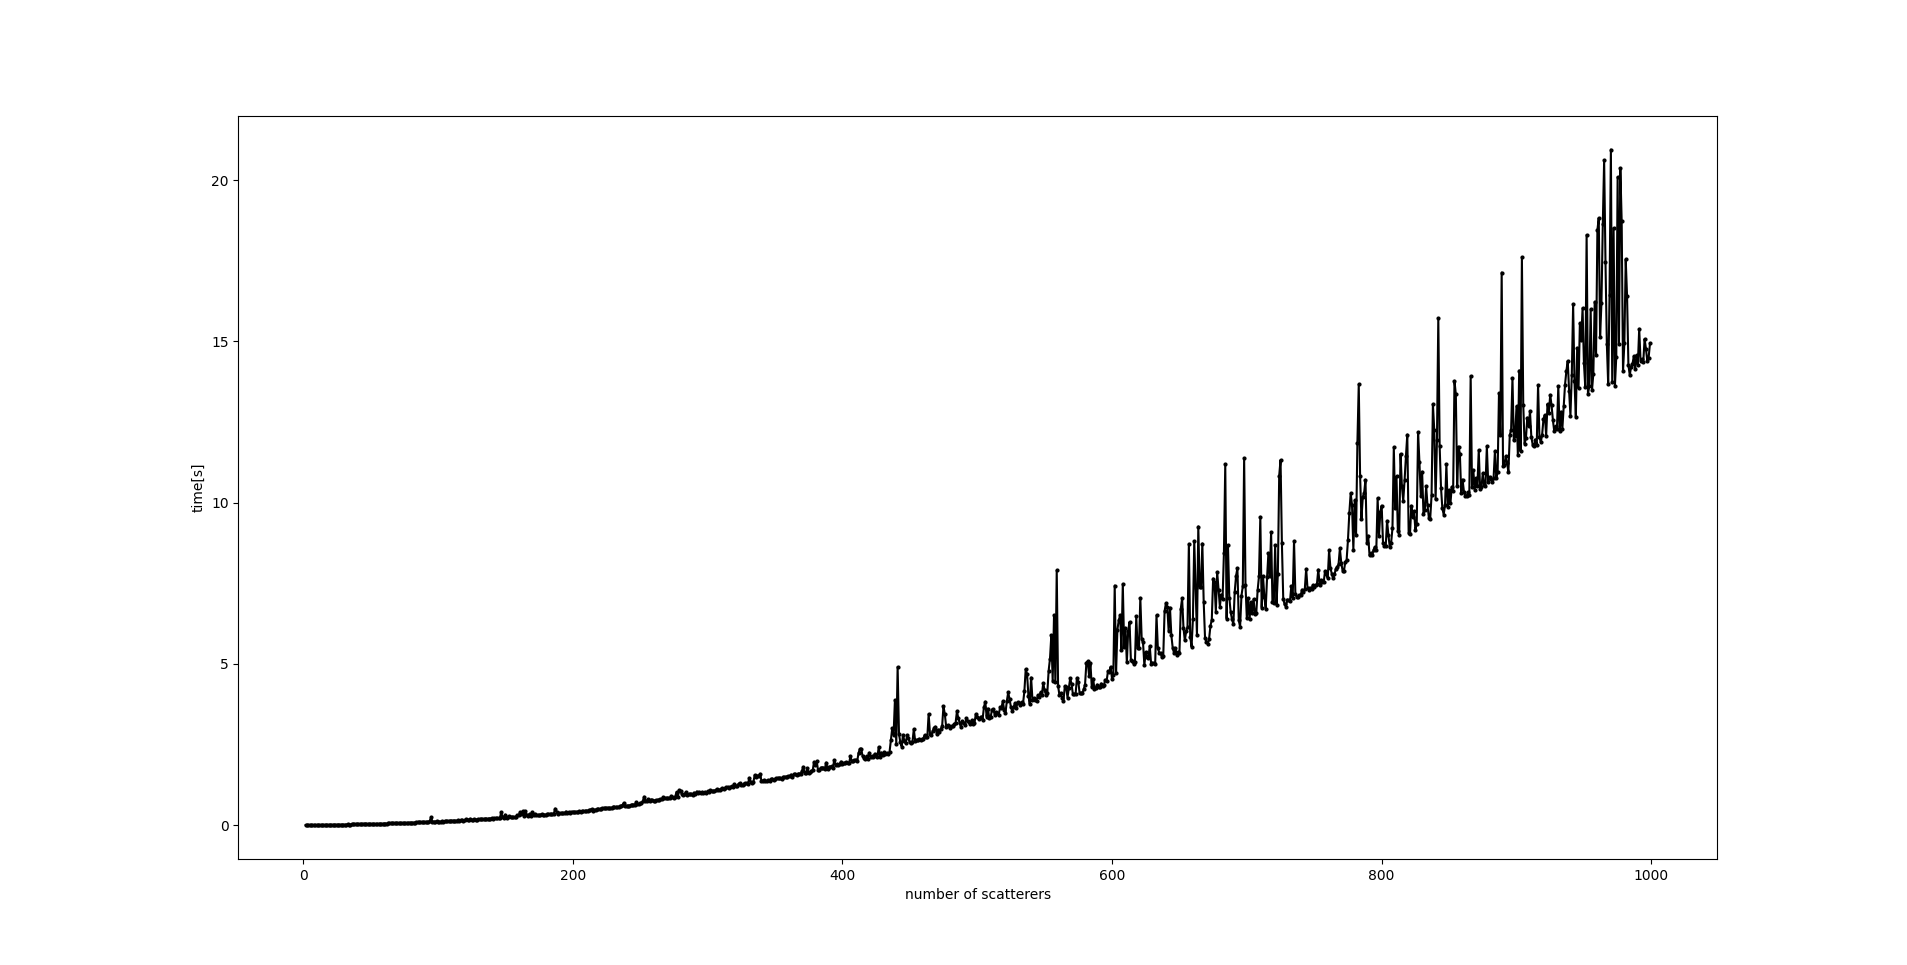

In [13]:

display(Image(filename='thesis_plots_data/placeholders/complexity_1.png'))
display(Image(filename='thesis_plots_data/placeholders/complexity_3.png'))

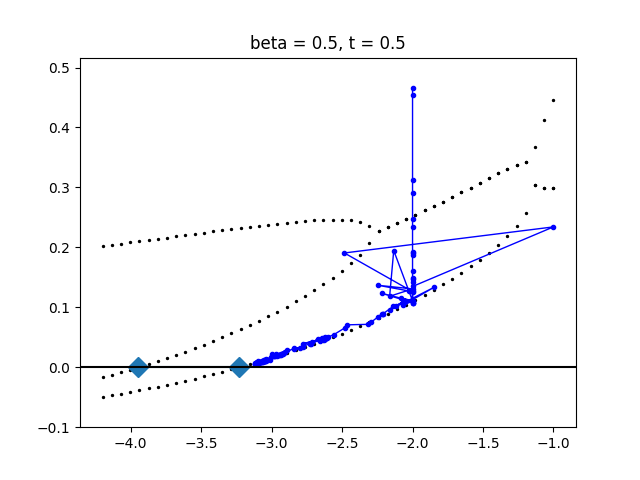

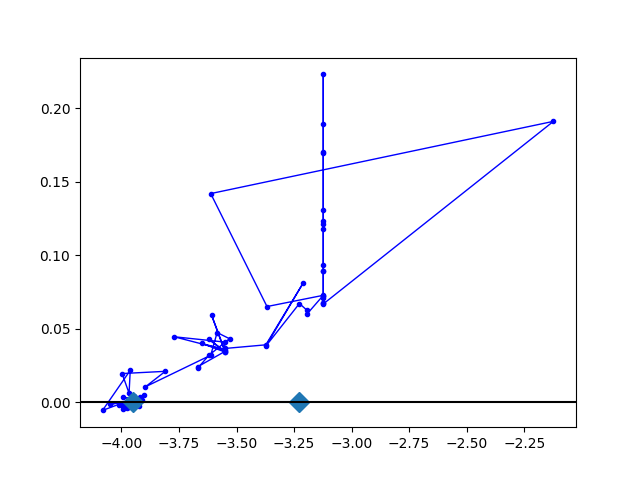

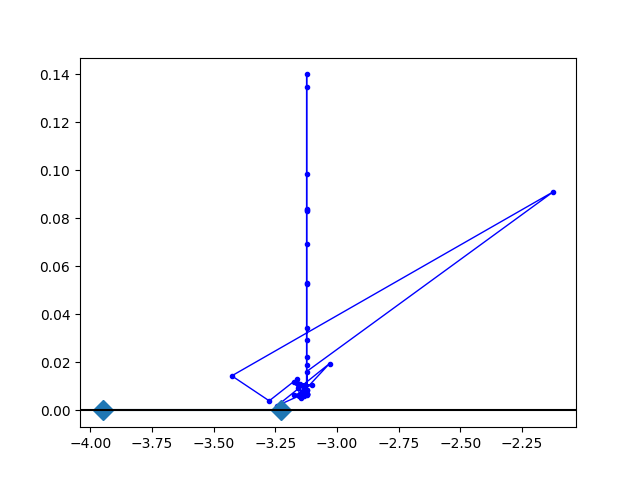

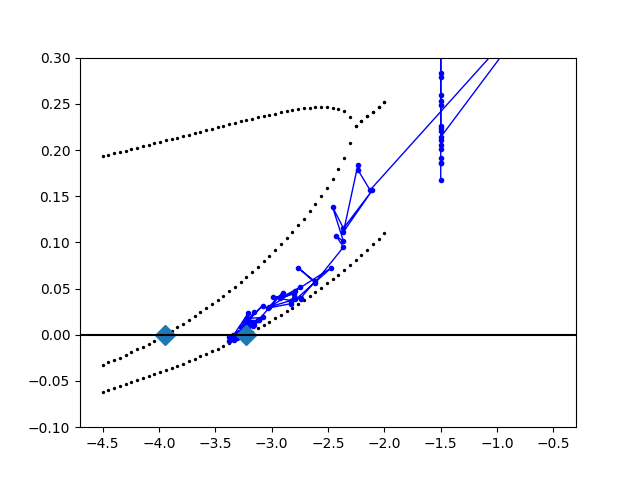

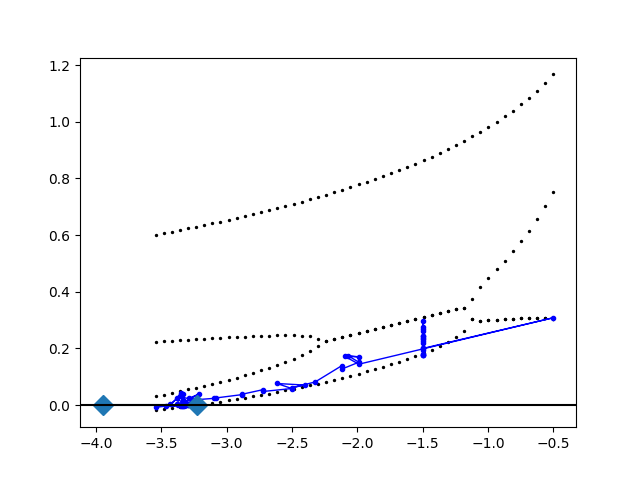

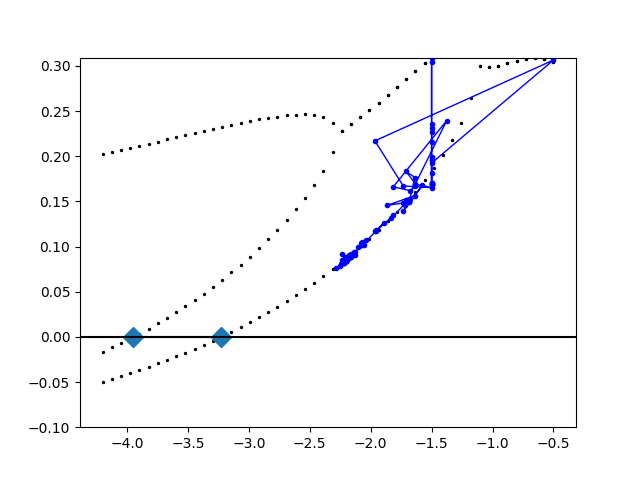

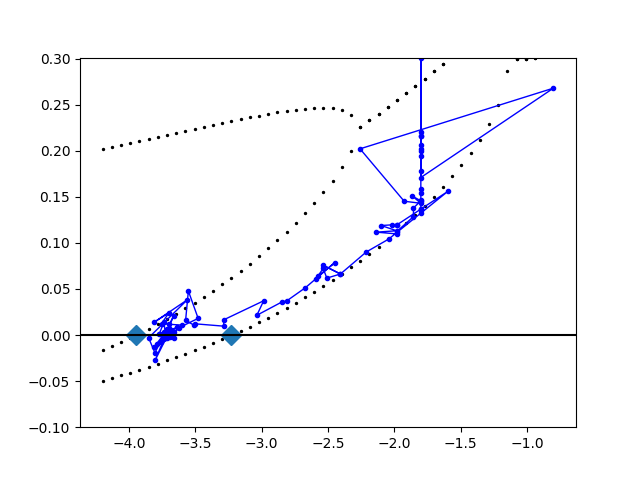

In [14]:

display(Image(filename='thesis_plots_data/placeholders/new_method+vqe/01.png'))
for i in range (1, 7):
    display(Image(filename=f'thesis_plots_data/placeholders/new_method+vqe/Figure_{i}.png'))



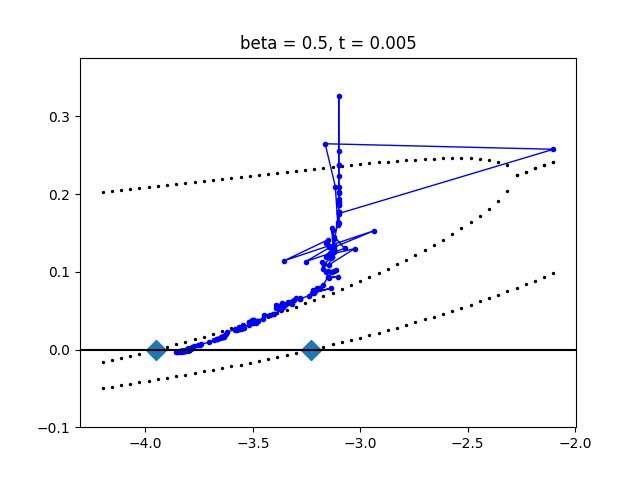

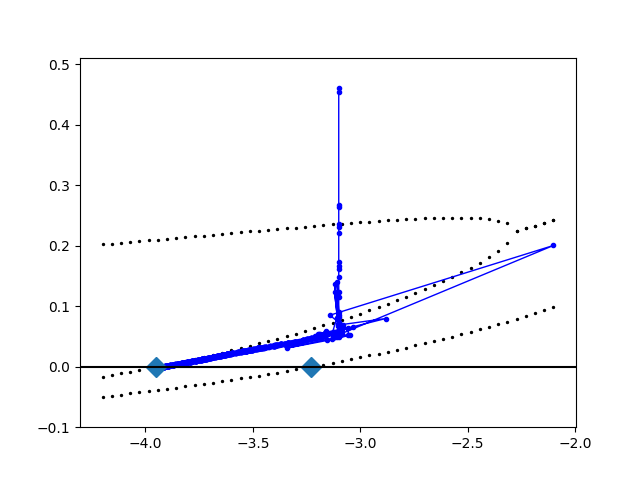

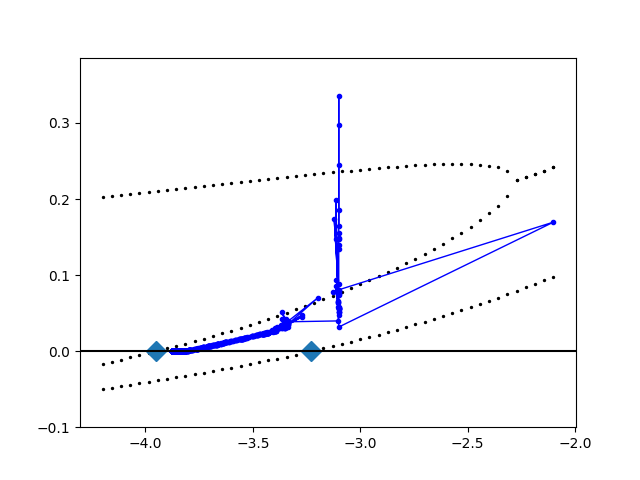

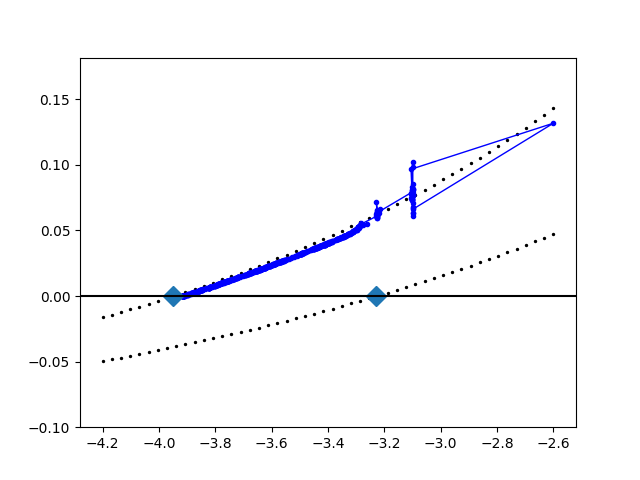

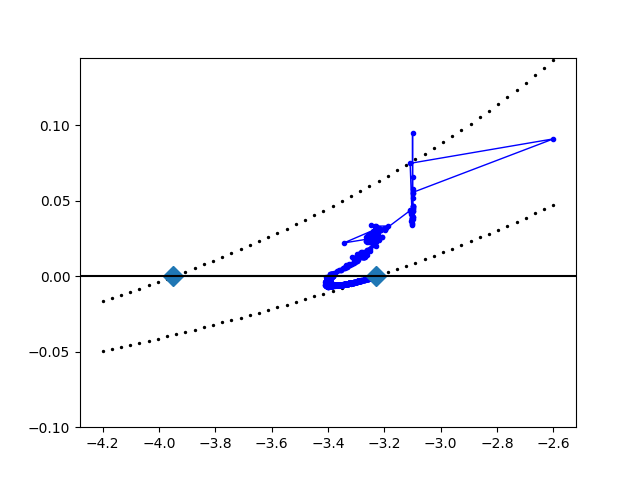

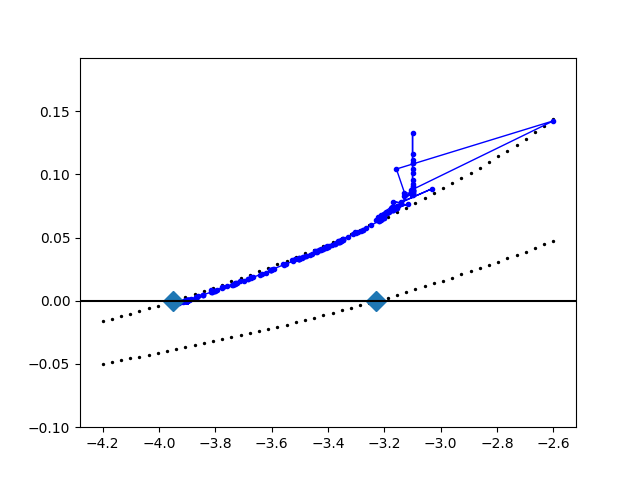

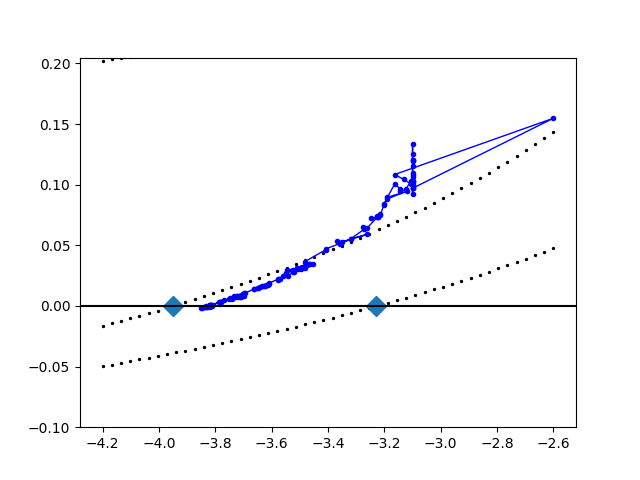

In [15]:
for i in range (1, 8):
    display(Image(filename=f'thesis_plots_data/placeholders/new_method+vqe/var{i}.png'))
